# New Workflow Component for Expanding Knowledge

This document introduces a proposed workflow enhancement, with **binning** as a case study to illustrate the justification for dataset reprocessing. Specifically, **Eukaryotic binning**, operational since **September 2022**, serves as an example.

## Summary of EukCC Bin Statistics and Taxonomic Distribution  

As of **January 23, 2025**, the following statistics have been compiled:

- **[Total Metagenomes with Bins: 25,146](https://img.jgi.doe.gov/cgi-bin/m/main.cgi?section=MetagenomeBins&page=bins&type=taxonomy)**  
- **Total Bins: 319,839**  
- **Total Metagenomes with EukCC Bins: 827**  
- **[Total EukCC Bins: 1,281](https://img.jgi.doe.gov/cgi-bin/m/main.cgi?section=MetagenomeBins&page=bindetail&taxonomy=ncbi&type=bytaxonomy&domain=Eukaryota&domain=Eukaryota%20EukCC%20Bins)**  

### Additional Notes  
The total number of EukCC bins has been exported as a TSV file (`data/exported_img_data-EukCC_bins.tsv`) using the IMG database link provided above. This file serves as a critical reference for downstream analyses.

---

## Analysis: EukCC Bin Counts per Metagenome  

An initial analysis was performed to evaluate the distribution of EukCC bins across metagenomes:  

- A histogram of EukCC bin counts per metagenome reveals that **most metagenomes contain a single EukCC bin**, with the maximum number of bins in a single metagenome being **9**.

---

## Analysis: EukCC Bin Taxonomy Distribution  

The taxonomy distribution analysis highlights a dominance of Eukaryota lineages. Key findings include:

- Significant representation of **Chlorophyta**, particularly within the **Mamiellophyceae** class and related orders.
- Prominent presence of **Ascomycota**, with notable classes such as **Lecanoromycetes**.  
- Recurring observations of fungal lineages such as **Basidiomycota** and **Tremellomycetes**.  

A **Sankey diagram** has been generated to visualize hierarchical taxonomic connections. The diagram illustrates the flow from higher-order taxa (e.g., **Eukaryota**) to specific families and genera, emphasizing dominant relationships and abundances within the dataset. 

A **Krona plot** provided another perspective to view the taxnomy distribution which is run through KronaTools v2.8.1 and can be generated by following command lines:

```js
awk -F"\t" '{print $5}' data/exported_img_data-EukCC_bins.txt  | sed -e 's/; /\t/g' | tail -n+2 > exported_img_data-EukCC_bins_for_krona.txt
ktImportText -q -o data/EukCC.krona.html exported_img_data-EukCC_bins_for_krona.txt 

```

---

## Conclusion  

This analysis demonstrates the value of reprocessing datasets with the proposed workflow component. By systematically updating processing methodologies, we can ensure more accurate and comprehensive insights into eukaryotic binning trends, enabling improved knowledge discovery and resource utilization.


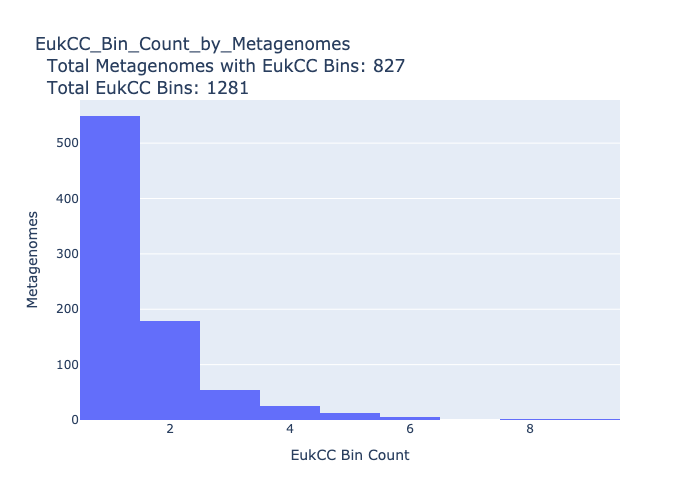

In [2]:
#Analysis: EukCC Bin Counts per Metagenome
import plotly.io as pio
pio.renderers.default = 'png'
import pandas as pd
import plotly.express as px

# Load the data
file_path = 'data/exported_img_data-EukCC_bins.tsv'
data = pd.read_csv(file_path, sep='\t')

total_EukCC_bins = len(data['IMG Genome ID'])
total_mtg_with_EukCC_bins = len(data['IMG Genome ID'].unique())

fig = px.histogram(
        data.groupby('IMG Genome ID')['bin_oid'].count(),
        title=f'EukCC_Bin_Count_by_Metagenomes<br>  Total Metagenomes with EukCC Bins: {total_mtg_with_EukCC_bins} <br>  Total EukCC Bins: {total_EukCC_bins}',
    )
fig.update_layout(xaxis_title='EukCC Bin Count', yaxis_title='Metagenomes',showlegend=False)
fig.show(renderer="png")

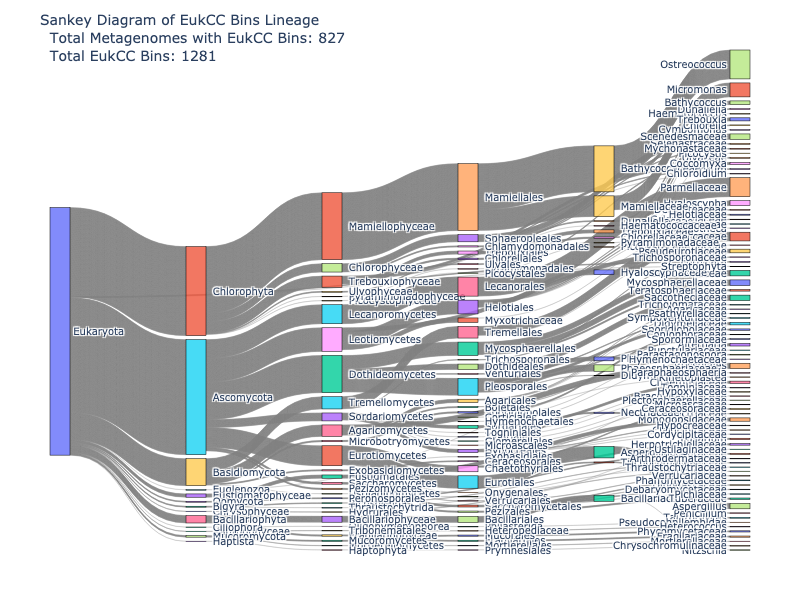

In [3]:
#Analysis: EukCC Bin Taxonomy Distribution  
import plotly.graph_objects as go

# Extract relevant columns for Sankey diagram from the above data
lineages = data['Bin Lineage'].dropna()
# Split lineages into hierarchical components
hierarchies = lineages.str.split(';')

# Create unique node labels
node_labels = list(set([level for lineage in hierarchies for level in lineage]))
node_indices = {label: idx for idx, label in enumerate(node_labels)}

# Generate Sankey diagram links
source = []
target = []
values = []

for lineage in hierarchies:
    for i in range(len(lineage) - 1):
        source.append(node_indices[lineage[i]])
        target.append(node_indices[lineage[i + 1]])
        values.append(1)  # Each occurrence adds a count

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        color="rgba(128,128,128, 0.2)",
        hovercolor="midnightblue"
    )
))

fig.update_layout(title_text=f"Sankey Diagram of EukCC Bins Lineage<br>  Total Metagenomes with EukCC Bins: {total_mtg_with_EukCC_bins} <br>  Total EukCC Bins: {total_EukCC_bins}", font_size=10, width=800,
    height=600, margin=dict(l=50, r=50, t=50, b=50))
fig.show(renderer="png")

# How much does the functional annotation assignment change

### We will use following dataset among the various versions of annotation workflows and count KO assignment for the initial analysis: 
#### SPRUCE
- **NMDC Study ID:** `nmdc:sty-11-33fbta56` / **GOLD Study ID:** `Gs0110138`  
At a minimum, we have recent re-annotations using version 5.2 (the latest version), both done with SPAdes. Time permitting, there are older records from earlier versions of SPAdes and the older MEGAHIT workflow (circa 2016/2017).

#### STEGEN Riverbed Sediment
- **NMDC Study ID:** `nmdc:sty-11-aygzgv51` / **GOLD Study ID:** `Gs0114663`  
Similar to SPRUCE, we have recent re-annotations done with SPAdes. Older records also exist, using earlier versions of SPAdes and the older MEGAHIT workflow.

#### CRESTED BUTTE
- **NMDC Study ID:** `nmdc:sty-11-dcqce727` / **GOLD Study ID:** `Gs0135149`  
Assemblies were created using MetaSPAdes v3.13.0 with annotation version v5.0.20 versus v5.2.0. Some older records were generated using SPAdes v3.11.1 with annotation version v4.16.4.

#### POPULUS
- **NMDC Study ID:** `nmdc:sty-11-1t150432` / **GOLD Study ID:** `Gs0103573`  
It includes both MEGAHIT and SPAdes assemblies. According to the data, NMDC reannotated the MEGAHIT assemblies in 2022, and we reran the annotation in 2024. Consider excluding this dataset if we have sufficient other data for analysis.

#### WET TROPICAL SOIL
- **NMDC Study ID:** `nmdc:sty-11-076c9980` / **GOLD Study ID:** `Gs0128850`  
Assemblies were created using SPAdes v3.12.0 or v3.13.0 with annotation version v4.16.5. NMDC reannotated the data with version 5.2.


### Dataset retrieval and staging
1. To get the most recent NMDC data, the mongo db.aggregate is performed to get Gold biosample ID, OMICS_PROCESSING_ID, workflow_execution_set IDs. 

- Here is an example for mongo db aggregation with SPRUCE dataset:
```js
        db.getCollection(
            'data_generation_set'
        ).aggregate(
        [
            {
                $match: {
                associated_studies: "nmdc:sty-11-33fbta56",
                analyte_category: "metagenome"
                }
            },
            {
                $lookup: {
                from: "biosample_set",
                localField: "has_input",
                foreignField: "id",
                as: "biosample_set"
                }
            },{
                    $lookup: {
                from: "workflow_execution_set",
                localField: "id",
                foreignField: "was_informed_by",
                as: "workflow_execution_set"
                }
            }
        ]
```
* The NMDC processed data will be on nersc at /global/cfs/cdirs/m3408/results/$OMICS_PROCESSING_ID/$workflow_execution_set_id.  The data will be symlink to staging area and using GOLD biosample ID(ex: `/global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE/Gb0139004`) as a subdirectory name. 

2. To Get older workflow version processed result from JGI/IMG, the [Gold API](https://gold-ws.jgi.doe.gov) and biosample ID from previous step to query analysis_projects to get ITSapID and IMG taxonOID. Using either ITSapID or IMG taxonOID, we use `jamo report` and `jamo fetch` commands to restore th PURGED/ARCHIVED annoation tar.gz files. 

- Here is an example of cmds using IMG taxonOID 3300009759:
```bash
    taxon_oid=3300009759
    ID=`jamo report select file_name,file_path,file_status,_id  where metadata.img.taxon_oid=$taxon_oid | grep gz| grep -E [0-9][0-9][0-9][0-9].tar.gz | grep PURGED | awk '{print $4}'` 
    if [ ! -z "${ID}" ]
    then
    jamo fetch id $ID
    fi
```
- Wait for the data been restored, we can then tar unzip data to staging area and using GOLD biosample ID(ex: Gb0139004) as a subdirectory name
```bash
    file=`jamo report select file_name,file_path,file_status,_id  where metadata.img.taxon_oid=$taxon_oid | grep gz| grep -E [0-9][0-9][0-9][0-9].tar.gz | awk '{print $2"/"$1}'` 
    tar -xvzf $file -C /global/cfs/cdirs/m3408/squads/reprocessing_samples/data/SPRUCE/Gb0139004
```

 

### Count Unique KO number, Total KO number and Total features number

* A script `get_ko_numbers.py` is written to count Unique KO number, Total KO number and Total features number for each dataset in `/global/cfs/cdirs/m3408/squads/reprocessing_samples/data`. The result is saved in a tab-delimited text (.tsv) [here](https://github.com/microbiomedata/nmdc_notebooks/tree/data_reprocessing_analysis/data_reprocessing_analysis/python/data) for each dataset. 
    * data/SPRUCE_stats.tsv
    * data/populus_stats.tsv
    * data/stegen_stats.tsv
    * data/wet_tropical_soil_stats.tsv
    * data/crested_stats.tsv

In [1]:

import pandas as pd
import plotly.express as px
df = pd.DataFrame()

# List of pipeline versions
versions = [
    "IMG Annotation Pipeline v.4.11.0",
    "IMG Annotation Pipeline v.4.11.2",
    "IMG Annotation Pipeline v.4.11.3",
    "IMG Annotation Pipeline v.4.11.4",
    "IMG Annotation Pipeline v.4.14.6",
    "IMG Annotation Pipeline v.4.15.1",
    "IMG Annotation Pipeline v.4.16.2",
    "IMG Annotation Pipeline v.4.16.4",
    "IMG Annotation Pipeline v.4.16.5",
    "IMG Annotation Pipeline v.5.0.20",
    "IMGAP Version: 5.2.0",
   #"Unknown"
]

# Function to create difference columns between two versions
def create_diff_columns(df, v1, v2):
    for metric in ['Unique_KO_count', 'Total_KO_count', 'Total_features_count']:
        col_name = f"{v2}_{v1}_{metric}_diff"
        df[col_name] = df[f"{v2} {metric}"] - df[f"{v1} {metric}"]
    return df

# Function to create ratio columns for a given pipeline version
def create_ratio_columns(df, version):
    # Create column names
    unique_ratio_col = f"{version} Unique_KO_ratio"
    total_ratio_col = f"{version} Total_KO_ratio"
    
    # Calculate ratios
    df[unique_ratio_col] = df[f"{version} Unique_KO_count"] / df[f"{version} Total_features_count"]
    df[total_ratio_col] = df[f"{version} Total_KO_count"] / df[f"{version} Total_features_count"]
    
    return df

for i in ['crested','SPRUCE','populus','stegen','wet_tropical_soil']:
    file_path = f'data/{i}_stats.tsv'
    data_raw = pd.read_csv(file_path, sep='\t', header=None)
    headers = data_raw.iloc[0] + " " + data_raw.iloc[1]
    data_merged = pd.read_csv(file_path, sep='\t', header=1)
    data_merged.columns = headers
    data_merged['env'] = i
    df = pd.concat([df,data_merged],ignore_index=True, sort=False)
    # Create difference columns for adjacent versions
    relevant_versions = [col for col in versions if any(col in head for head in data_merged.columns)]
    print('env:' + i)
    print(relevant_versions)
    for i in range(len(relevant_versions) - 1):
        df = create_diff_columns(df, relevant_versions[i], relevant_versions[i+1])



# Create ratio columns for each version
for version in versions:
    df = create_ratio_columns(df, version)

df = df.reindex(sorted(df.columns), axis=1)
# Save the updated dataframe to a new tab-delimited file
df.to_csv('data/Merged_stats_with_ratios_and_diff.txt', sep='\t', index=False)



env:crested
['IMG Annotation Pipeline v.4.16.4', 'IMG Annotation Pipeline v.5.0.20', 'IMGAP Version: 5.2.0']
env:SPRUCE
['IMG Annotation Pipeline v.4.11.2', 'IMG Annotation Pipeline v.4.11.3', 'IMG Annotation Pipeline v.4.14.6', 'IMG Annotation Pipeline v.4.15.1', 'IMG Annotation Pipeline v.4.16.2', 'IMGAP Version: 5.2.0']
env:populus
['IMG Annotation Pipeline v.4.11.0', 'IMG Annotation Pipeline v.4.16.2', 'IMGAP Version: 5.2.0']
env:stegen
['IMG Annotation Pipeline v.4.11.4', 'IMG Annotation Pipeline v.4.16.2', 'IMG Annotation Pipeline v.5.0.20', 'IMGAP Version: 5.2.0']
env:wet_tropical_soil
['IMG Annotation Pipeline v.4.15.1', 'IMG Annotation Pipeline v.4.16.5', 'IMGAP Version: 5.2.0']


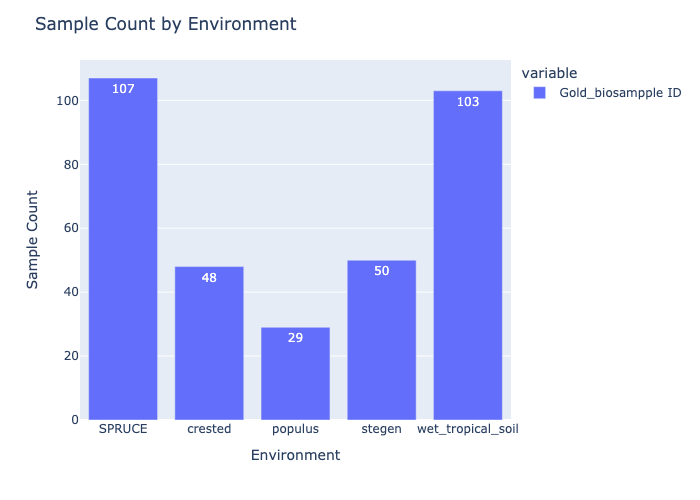

In [3]:
sample_count_df=df.groupby('env').count()['Gold_biosampple ID'] 
import plotly.io as pio
pio.renderers.default = 'png'

fig=px.bar(sample_count_df,text_auto=True)
fig.update_layout(yaxis_title='Sample Count',xaxis_title='Environment',title='Sample Count by Environment')
fig.show(renderer="png")